# Demo: building a satellite time-stack with `sat-tile-stack`

This notebook is a 5-cell tour of `sat_tile_stack.sattile_stack(...)`,
the top-level function that pulls a daily, multi-band Sentinel-2 time
series around a point of interest from the Microsoft Planetary Computer
STAC and lands it as an analysis-ready `xarray.DataArray`.

We don't pick a Greenland lake for the demo, because the package is
not lake-specific. Instead we point at the Port of Oakland container
terminal and watch ship traffic come and go over a few weeks. Same
function, different AOI.

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer

from sat_tile_stack import sattile_stack

print('imports OK')


imports OK


## Build the stack

Open a STAC client against Microsoft Planetary Computer, then call
`sattile_stack(...)` with a point, the bands we want, and a date range.
The function does the STAC search, builds a 4D `(time, band, y, x)`
array via `stackstac`, resamples to daily cadence, crops to a square
tile around the centroid, and (because `pull_to_mem=True`) loads it
all into memory with a dask progress bar.

In [7]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
print('connected to Microsoft Planetary Computer')

# Point of interest: Port of Oakland container terminal
centroid   = (-122.33, 37.81)   # (lon, lat)
time_range = '2019-08-01/2019-08-30'
band_names = ['B04', 'B03', 'B02']   # RGB

stack = sattile_stack(
    catalog,
    centroid,
    band_names,
    collection='sentinel-2-l2a',
    pix_res=10,
    tile_size=256,
    time_range=time_range,
    cadence='D',
    cloudmask=False,
    pull_to_mem=True,
)
# sattile_stack returns an xarray.Dataset (multiple bands as separate
# data variables alongside the per-timestep coords).
print(f'stack dims:  {dict(stack.sizes)}')
print(f'data vars:   {list(stack.data_vars)}')
print(f'time range:  {str(stack.time.values[0])[:10]} ... {str(stack.time.values[-1])[:10]}')


connected to Microsoft Planetary Computer
Pulling stack into memory: 6 scenes -> vars ['reflectance'], dims {'x': 256, 'y': 256, 'time': 30, 'band': 3} (this is network/IO-bound; minutes per full-season 512^2 lake)
[########################################] | 100% Completed | 314.41 ms
Stack loaded, vars: ['reflectance']
stack dims:  {'x': 256, 'y': 256, 'time': 30, 'band': 3}
data vars:   ['reflectance']
time range:  2019-08-01 ... 2019-08-30


## What did we get back?

`stack` is an `xarray.DataArray` with `(time, band, y, x)` dimensions.
Coordinates carry per-timestep cloud-cover metadata (from the underlying
STAC items) and per-band names. Everything is lazy-friendly: we asked
for `pull_to_mem=True` here so the array is in RAM, but you can omit
that flag and pass the dask-backed array straight into a downstream
pipeline.

In [8]:
print('--- coords on the time axis ---')
for c in ('eo_cloud_cover', 'pct_nans', 'processing_baseline'):
    if c in stack.coords:
        vals = stack[c].values
        sample = vals[:3] if vals.dtype != object else list(vals[:3])
        print(f'  {c}: shape={vals.shape}  sample={sample}')

print('\n--- bands ---')
print(f'  band axis (int): {list(stack.band.values)}')
print(f'  band_name coord: {list(stack.band_name.values)}')


--- coords on the time axis ---
  eo_cloud_cover: shape=(30,)  sample=[      nan       nan 51.171966]
  pct_nans: shape=(30,)  sample=[100. 100.   0.]
  processing_baseline: shape=(30,)  sample=['' '' '02.12']

--- bands ---
  band axis (int): [np.int32(0), np.int32(1), np.int32(2)]
  band_name coord: [np.str_('B04'), np.str_('B03'), np.str_('B02')]


## Plot a few daily RGB composites

A quick visual check. We pick three clear-ish days from the stack
(low `eo_cloud_cover`) and render them as true-color RGB.

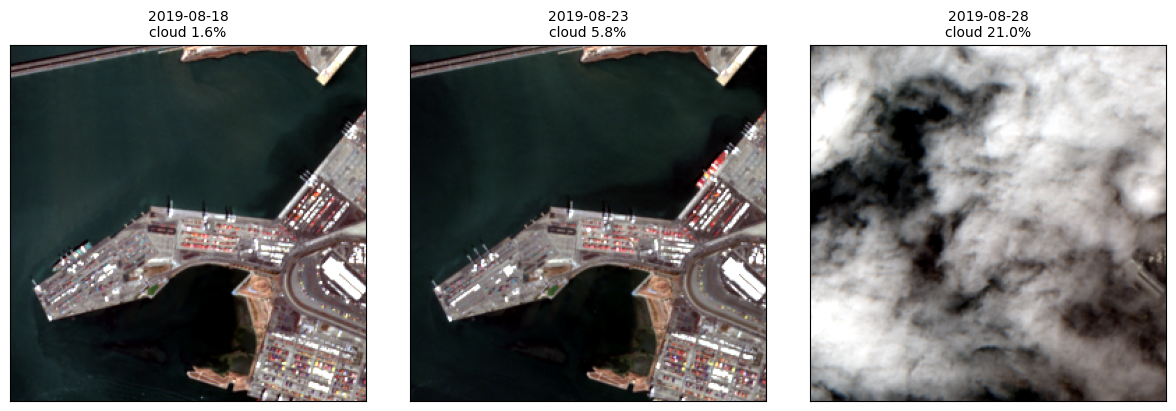

In [9]:
def _stretch(rgb, pmin=2, pmax=98):
    out = np.empty_like(rgb, dtype=float)
    for i in range(3):
        lo, hi = np.nanpercentile(rgb[..., i], (pmin, pmax))
        out[..., i] = np.clip((rgb[..., i] - lo) / max(hi - lo, 1e-9), 0, 1)
    return out

# Look up integer band indices from band_name (the `band` dim is 0..N-1
# integers; band names live on the `band_name` aux coord).
bnames = list(stack.band_name.values)
ri, gi, bi = (bnames.index(b) for b in ('B04', 'B03', 'B02'))

clear_idx = np.argsort(stack.eo_cloud_cover.values)[:3]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, t in zip(axes, sorted(clear_idx)):
    sl = stack['reflectance'].isel(time=int(t))   # (band, y, x)
    rgb = np.stack([sl.isel(band=i).values for i in (ri, gi, bi)], axis=-1)
    ax.imshow(_stretch(rgb))
    cc = float(stack.eo_cloud_cover.isel(time=int(t)).values)
    ax.set_title(f"{str(stack.time.values[int(t)])[:10]}\ncloud {cc:.1f}%", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.show()


## Where to go next

- **Co-register auxiliary layers** (lake polygons, NDWI water masks,
  scalar time series) onto the stack with the `coregister.add_*`
  family. See `sat_tile_stack.coregister`.
- **Label per-area stacks** in a browser GUI with the `lakelabel`
  console script (install with `pip install sat-tile-stack[labeling]`).
- **Validate the per-area NetCDFs** for CF-1.8 compliance with
  `sts-cf-check <dir>` or `cf_check.cf_check(paths, ...)`.

For the data-product example — what a fully-built, co-registered,
labeled NetCDF looks like — open `demo_essd_readdata.ipynb`.